In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Display graphs inside the notebook
%matplotlib inline

#Better plot style
plt.style.use("ggplot")

In [3]:
#Load dataset
df = pd.read_csv("../dataset/Housing.csv")

# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [5]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [11]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
356,3773000,2520,5,2,1,no,no,yes,no,yes,1,no,furnished
329,3990000,3960,3,1,2,yes,no,no,no,no,0,no,furnished
390,3500000,2135,3,2,2,no,no,no,no,no,0,no,unfurnished
227,4690000,6000,2,1,1,yes,no,yes,no,yes,1,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [12]:
print("Target Variable:", df["price"].name)

Target Variable: price


# Dataset Exploration Summary

- Dataset contains 545 rows and 13 columns.
- Target variable is 'price'.
- Dataset has both numerical and categorical features.
- Checked for missing values.
- Checked for duplicate rows.
- Identified data types for all columns.
- Dataset is ready for preprocessing in the next phase.

In [13]:
# Create a copy to preserve the original dataset
data = df.copy()

# Display first 5 rows
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
print("Duplicate Rows:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicate Rows after removal:", data.duplicated().sum())

Duplicate Rows: 0
Duplicate Rows after removal: 0


In [16]:
categorical_columns = data.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


C:\Users\LOQ\AppData\Local\Temp\ipykernel_4684\4168105086.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=["object"]).columns


In [18]:
data_encoded = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True
)

data_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [19]:
print(data_encoded.shape)
data_encoded.head()

(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [20]:
x = data_encoded.drop("price", axis=1)
y = data_encoded["price"]

print("Features:", x.shape)
print("Target:", y.shape)

Features: (545, 13)
Target: (545,)


In [21]:
from sklearn.model_selection import train_test_split


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", x_train.shape)
print("Testing Set:", x_test.shape)

Training Set: (436, 13)
Testing Set: (109, 13)


In [26]:
x_train.dtypes

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

In [27]:
feature_names = x.columns.tolist()

print(feature_names)

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


# Data Preprocessing Summary

- Created a copy of the original dataset.
- Checked for missing values.
- Removed duplicate rows (if any).
- Identified categorical features.
- Applied One-Hot Encoding using 'pd.get_dummies()'.
- Separated features ('x') and target ('y').
-  Split the dataset into training and testing sets (80:20).
- Saved the list of feature names for future use.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [33]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    
    # Train the model
    model.fit(x_train, y_train)
    
    # Make predictions
    predictions = model.predict(x_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print(f"\n{model.__class__.__name__}")
    print("-" * 40)
    print(f"MAE : {mae:.2f}")    
    print(f"MSE : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R^2 : {r2:.2f}")
    
    return {
        "Model": model.__class__.__name__,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 SCORE": r2
    }

In [34]:
linear_model = LinearRegression()

linear_results = evaluate_model(
    linear_model,
    x_train,
    x_test,
    y_train,
    y_test
)


LinearRegression
----------------------------------------
MAE : 970043.40
MSE : 1754318687330.66
RMSE : 1324506.96
R^2 : 0.65


In [35]:
decision_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=8
)

decision_results = evaluate_model(
    decision_tree,
    x_train,
    x_test,
    y_train,
    y_test
)


DecisionTreeRegressor
----------------------------------------
MAE : 1263287.97
MSE : 2882916462917.18
RMSE : 1697915.33
R^2 : 0.43


In [36]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_results = evaluate_model(
    random_forest,
    x_train,
    x_test,
    y_train,
    y_test
)


RandomForestRegressor
----------------------------------------
MAE : 1021546.04
MSE : 1961585044320.34
RMSE : 1400565.97
R^2 : 0.61


In [37]:
results = [
    linear_results,
    decision_results,
    forest_results
]

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 SCORE
0,LinearRegression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,DecisionTreeRegressor,1.263288e+06,2.882916e+12,1.697915e+06,0.429642
2,RandomForestRegressor,1.021546e+06,1.961585e+12,1.400566e+06,0.611919


In [39]:
print(results_df.columns.tolist())

['Model', 'MAE', 'MSE', 'RMSE', 'R2 SCORE']


In [41]:
results_df.sort_values(
    by="R2 SCORE",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 SCORE
0,LinearRegression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,RandomForestRegressor,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
1,DecisionTreeRegressor,1.263288e+06,2.882916e+12,1.697915e+06,0.429642


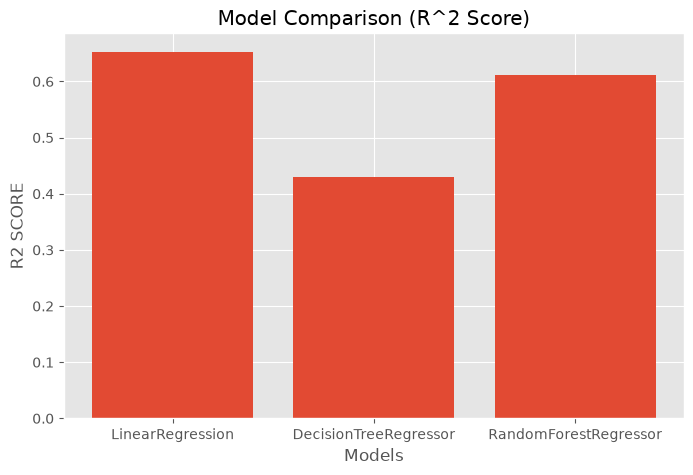

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 SCORE"]    
)
plt.title("Model Comparison (R^2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 SCORE")

plt.show()

In [47]:
best_model = random_forest

print("Best Model:", best_model.__class__.__name__)

Best Model: RandomForestRegressor


# Model Training Summary

Three regression models were trained:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The model were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R^2 Score

The model with the highest R^2 Score and the lowest prediction error was selected as the final model for deployment.

In [48]:
import joblib
import os

In [49]:
os.makedirs("../model", exist_ok=True)

In [50]:
joblib.dump(best_model, "../model/house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [51]:
joblib.dump(feature_names, "../model/feature_names.pkl")

print("Feature names saved!")

Feature names saved!


In [52]:
os.listdir("../model")

['feature_names.pkl', 'house_price_model.pkl']

In [53]:
loaded_model = joblib.load("../model/house_price_model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [54]:
loaded_features = joblib.load("../model/feature_names.pkl")

print(loaded_features)

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [56]:
with open("../model/model_info.txt", "w") as file:
    file.write("CozyNest House Price Prediction Model\n")
    file.write("-------------------------------------\n")
    file.write(f"Best Model: {best_model.__class__.__name__}\n")
    file.write(f"Number of Features: {len(feature_names)}\n")
    
print("Model information saved!")

Model information saved!


# Model Saving Summary

The best-perfoming regression model was saved using Joblib.

The feature names were also saved to ensure that future predictions receive inputs in the correct order.

The saved model and feature list will be loaded by the Flask backend to make real-time predictions from the CozyNest website.